In [1]:
from pathlib import Path
import pandas as pd
import polars as pl
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
from src.sugar_jepa.sugar_jepa_model import JepaEncoder
import lightning as L
from torch.utils.data import DataLoader, Dataset
from sugar_one.train_sugar_one import load_splits_streaming, impute_and_sort
from sugar_jepa.jepa_pretrain import GlucoseWindowDataset
from sugar_one.console_log import echo_plain
from lightning.pytorch.callbacks import TQDMProgressBar

ENCODER_128 = Path("runs/jepa-encoder/jepa-encoder-128.pt")
ENCODER_288 = Path("runs/jepa-encoder/jepa-encoder-288.pt")
DATA = Path("data/input/loop_ai_ready_joined2.csv")
WINDOW_STEPS = 128
WINDOW_STRIDE = 4

In [2]:
data = pd.read_csv(DATA)
data.head()

,sequence_id,Timestamp,Event Type,User ID,Glucose (mg/dL),Basal Rate (U/h),Bolus Insulin (U),Carbohydrates (g),Recommended Split,Study Group
0,L-1061,2018-07-09T20:58:00,EGV,loop_1004,136.641,NaN,NaN,NaN,train,T1DM
1,L-1061,2018-07-09T21:03:00,EGV,loop_1004,138.310,NaN,NaN,NaN,train,T1DM
2,L-1061,2018-07-09T21:08:00,EGV,loop_1004,139.344,NaN,NaN,NaN,train,T1DM
3,L-1061,2018-07-09T21:13:00,EGV,loop_1004,140.326,NaN,NaN,NaN,train,T1DM
4,L-1061,2018-07-09T21:18:00,EGV,loop_1004,141.996,NaN,NaN,NaN,train,T1DM


In [3]:
data.describe()

,Glucose (mg/dL),Basal Rate (U/h),Bolus Insulin (U),Carbohydrates (g)
count,1.209099e+07,1.574434e+06,190146.000000,123399.000000
mean,1.351555e+02,4.298428e-01,2.237043,29.507846
std,4.686700e+01,9.656829e-01,2.622649,22.235223
min,3.900000e+01,0.000000e+00,0.030000,0.000000
25%,1.040000e+02,0.000000e+00,0.500000,14.000000
50%,1.240000e+02,0.000000e+00,1.350000,25.000000
75%,1.549510e+02,5.900000e-01,3.000000,40.000000
max,4.010000e+02,3.600000e+01,28.200000,283.960000


In [4]:
users = data[['User ID', 'sequence_id', 'Study Group']].set_index('User ID')
users.head()

,sequence_id,Study Group
User ID,,
loop_1004,L-1061,T1DM
loop_1004,L-1061,T1DM
loop_1004,L-1061,T1DM
loop_1004,L-1061,T1DM
loop_1004,L-1061,T1DM


In [5]:
seq_by_user = users.groupby('User ID')['sequence_id'].count()
seq_by_user.head()

User ID
ai_ready_1001    2856
ai_ready_1002    2238
ai_ready_1003    2679
ai_ready_1004    2856
ai_ready_1005    2544
Name: sequence_id, dtype: int64

In [6]:
seq_by_user.describe()

count      2292.000000
mean       5275.301483
std       16556.792165
min         219.000000
25%        2756.750000
50%        2853.000000
75%        2856.000000
max      150512.000000
Name: sequence_id, dtype: float64

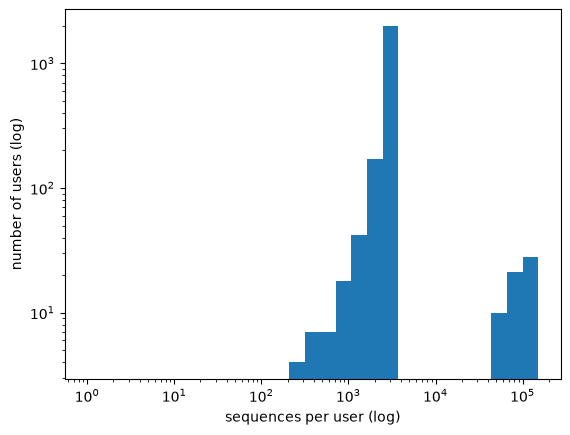

In [7]:
plt.hist(seq_by_user.values, bins=np.logspace(0, np.log10(seq_by_user.max()), 30))
plt.xscale('log')
plt.xlabel('sequences per user (log)')
plt.yscale('log')
plt.ylabel('number of users (log)')
plt.show()

In [8]:
seq_by_user = (
    users.groupby('User ID')['sequence_id'].count()
    .reset_index(name='n_sequences')
)
seq_by_user['dataset'] = seq_by_user['User ID'].str.rsplit('_', n=1).str[0]
seq_by_user.groupby('dataset')['n_sequences'].sum()

dataset
ai_ready    6027765
loop        6063226
Name: n_sequences, dtype: int64

In [9]:
seq_by_user.groupby('dataset')['User ID'].count()

dataset
ai_ready    2232
loop          60
Name: User ID, dtype: int64

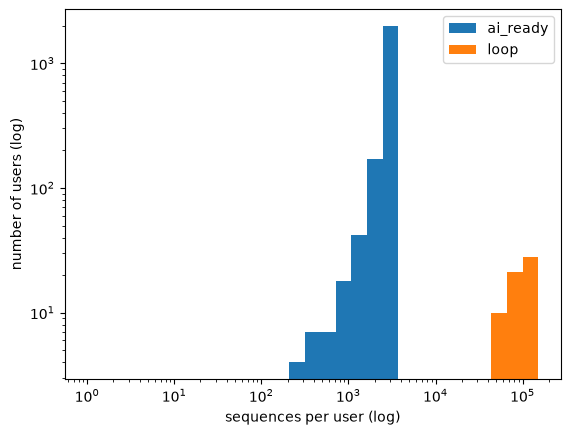

In [10]:
groups = seq_by_user.groupby('dataset')['n_sequences']
labels = list(groups.groups.keys())
data = [g.values for _, g in groups]

bins = np.logspace(0, np.log10(seq_by_user['n_sequences'].max()), 30)

plt.hist(data, bins=bins, stacked=True, label=labels)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('sequences per user (log)')
plt.ylabel('number of users (log)')
plt.legend()
plt.show()

In [11]:
COL_USER = "User ID"

train_df, val_df, test_df = load_splits_streaming(
  DATA,
  "sequence_id",
  keep_columns=("User ID", ),
  drop_interpolated=False,
)

train_df = impute_and_sort(train_df)
train_df.head()

Loading train/val/test splits (streaming)...
  ... loaded 12,090,991 rows total


unique_id,ds,split,study_group,event_type,glucose,basal,bolus,carbs,User ID
str,datetime[μs],str,str,str,f32,f32,f32,f32,str
"""A-1""",2023-07-27 23:50:00,"""train""","""pre_diabetes_lifestyle_control…","""AI_READY""",113.0,0.0,0.0,0.0,"""ai_ready_1001"""
"""A-1""",2023-07-27 23:55:00,"""train""","""pre_diabetes_lifestyle_control…","""AI_READY""",117.0,0.0,0.0,0.0,"""ai_ready_1001"""
"""A-1""",2023-07-28 00:00:00,"""train""","""pre_diabetes_lifestyle_control…","""AI_READY""",121.0,0.0,0.0,0.0,"""ai_ready_1001"""
"""A-1""",2023-07-28 00:05:00,"""train""","""pre_diabetes_lifestyle_control…","""AI_READY""",125.0,0.0,0.0,0.0,"""ai_ready_1001"""
"""A-1""",2023-07-28 00:10:00,"""train""","""pre_diabetes_lifestyle_control…","""AI_READY""",121.0,0.0,0.0,0.0,"""ai_ready_1001"""


In [12]:
def generate_user_map(df: pl.DataFrame):
  unique_users = list(set(df['User ID'].to_list()))
  return { u: i for i, u in enumerate(unique_users) }

In [13]:
class GlucoseWindowDataset(Dataset):
  def __init__(self, df: pl.DataFrame, window: int, stride: int = 1):
    if stride < 1:
      raise ValueError(f"stride must be >= 1, got {stride}")

    self.window = window
    self._series: list[np.ndarray] = []
    self._index: list[tuple[int, int]] = []
    self._users: list[int] = []
    self._user_map = generate_user_map(df)
    self.n_users = len(self._user_map)
    n_skipped = 0

    for (_uid,), grp in (
      df.sort(["unique_id", "ds"]).group_by(["unique_id"], maintain_order=True)
    ):
      g = grp["glucose"].to_numpy().astype(np.float32)
      n_windows = len(g) - window + 1
      if n_windows <= 0:
        n_skipped += 1
        continue
      si = len(self._series)
      self._series.append(g)
      self._users.append(self._user_map[grp["User ID"][0]])
      for start in range(0, n_windows, stride):
        self._index.append((si, start))

    if n_skipped:
      echo_plain(f"  Note: skipped {n_skipped} series shorter than {window} steps.")

  def __len__(self) -> int:
    return len(self._index)

  def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
    si, start = self._index[idx]
    user = self._users[si]
    return torch.from_numpy(self._series[si][start : start + self.window]), user


In [14]:
train_ds = GlucoseWindowDataset(train_df, window=WINDOW_STEPS, stride=WINDOW_STRIDE)
val_ds = GlucoseWindowDataset(val_df, window=WINDOW_STEPS, stride=WINDOW_STRIDE)
test_ds = GlucoseWindowDataset(test_df, window=WINDOW_STEPS, stride=WINDOW_STRIDE)

train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=256)
test_dl = DataLoader(test_ds, batch_size=256)

Note: skipped 65 series shorter than 128 steps.

Note: skipped 20 series shorter than 128 steps.

Note: skipped 21 series shorter than 128 steps.

In [15]:
class PatientPredictor(nn.Module):
  def __init__(
    self,
    encoder: JepaEncoder,
    num_classes: int,
  ) -> None:
    super().__init__()
    jepa_dim = encoder.embed_dim

    self.encoder = encoder
    self.encoder.requires_grad_(False)
    self.encoder.eval()
    self.head = nn.Linear(
      in_features=jepa_dim,
      out_features=num_classes,
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
      z = self.encoder(x)

    pooled = z.mean(dim=1)

    return self.head(pooled)

In [16]:
encoder = JepaEncoder(n_time_steps=WINDOW_STEPS, patch_size=8, embed_dim=96, n_layers=3, n_heads=6)

encoder.load_state_dict(torch.load(ENCODER_128, map_location="cpu", weights_only=True))

predictor = PatientPredictor(encoder, num_classes=train_ds.n_users)

In [17]:
import torch.nn.functional as F

class LightningModel(L.LightningModule):
  def __init__(self, model: PatientPredictor) -> None:
    super().__init__()
    self.model = model

  def _step(self, batch, stage: str):
    x, y = batch
    logits = self.model(x)
    loss = F.cross_entropy(logits, y)
    acc = (logits.argmax(dim=-1) == y).float().mean()
    self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True)
    self.log(f"{stage}_acc", acc, prog_bar=True, on_epoch=True)
    return loss

  def training_step(self, batch):
    return self._step(batch, "train")

  def validation_step(self, batch):
    return self._step(batch, "val")

  def configure_optimizers(self):
    optimizer = torch.optim.Adam(self.model.head.parameters(), lr=1e-3)
    return optimizer

In [ ]:
from lightning.pytorch.callbacks import TQDMProgressBar

model = LightningModel(predictor)

trainer = L.Trainer(
    max_epochs=15,
    enable_checkpointing=False,
    logger=True,
    callbacks=[TQDMProgressBar(refresh_rate=10)],
)
trainer.fit(model, train_dl, val_dl)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ PatientPredictor │  490 K │ train │     0 │
└───┴───────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 153 K                                                                                            
Non-trainable params: 336 K                                                                                        
Total params: 490 K                                                                                                
Total estimated model params size (MB): 1.962                                                                      
Modules in train mode: 2                                                                                           
Modules in eval mode: 38                                                                                           
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/alegator1209/Documents/KSE/term-3/audio/glucose-forecasting/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/alegator1209/Documents/KSE/term-3/audio/glucose-forecasting/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/alegator1209/Documents/KSE/term-3/audio/glucose-forecasting/.venv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:538: Found 38 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentio

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [75]:
batch = next(iter(dl))
glucose, patients = batch

print(glucose.shape)
logits = predictor(glucose)
y = logits.argmax(dim=-1)
print(len(patients))
print(y.shape)

print(f"Patient[0] = {patients[0]}, y[0] = {y[0]}")

torch.Size([256, 128])
256
torch.Size([256])
Patient[0] = 407, y[0] = 1114
